# Mean Forecast Policy Variants

This notebook compares two order-trigger variants under an identical calibrated
safety-stock factor:
- **Order-up-to** (`OrderUpToTrigger`) -- orders every review period to bring inventory
  position up to a target.
- **Reorder-point** (`ReorderPointTrigger`) -- only orders when inventory position drops
  to or below a computed reorder point.

**Scope note (Task 14 rewrite):** janrth's original notebook also compared a
"lead-time sum forecast" policy variant (`build_lead_time_forecast_article_configs_from_standard_rows`)
and swept an aggregation window (`optimize_aggregation_and_service_level_factors`). Neither
of those was ported into this repo -- see `io_.py`'s module docstring -- so this rewrite
narrows the comparison to the two `OrderTrigger` variants this repo actually has
(`OrderUpToTrigger`, `ReorderPointTrigger`), both driven by `SqrtHorizonSafetyStock` and
calibrated per article via `calibration.optimize`. Article count is reduced from the
original 200 to keep demo runtime reasonable.

In [1]:
from dataclasses import replace
import random

import pandas as pd

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import SqrtHorizonSafetyStock
from replenishment.strategies.order_trigger import OrderUpToTrigger, ReorderPointTrigger
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters

In [2]:
review_period = 3
forecast_horizon = 3

## 1) Generate Sample Data

In [3]:
history_mean = 20.0
history_std = 5.0
forecast_mean = 15.0
forecast_std = 4.0

rows = generate_standard_simulation_rows(
    n_unique_ids=10,
    periods=60,
    history_mean=history_mean,
    history_std=history_std,
    forecast_mean=forecast_mean,
    forecast_std=forecast_std,
    forecast_start_period=30,
    lead_time=3,
    initial_on_hand=25,
    current_stock=25,
    seed=7,
)
backtest_rows, evaluation_rows = split_standard_simulation_rows(rows)

rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

evaluation_rows = [
    replace(row, actuals=_sample_int(history_mean, history_std), demand=_sample_int(history_mean, history_std))
    for row in evaluation_rows
]

rows_df = standard_simulation_rows_to_dataframe(backtest_rows + evaluation_rows, library="pandas")
print(f"backtest rows: {len(backtest_rows)}, forecast rows: {len(evaluation_rows)}")

candidate_factors = [.50, .60, .70, .80, .90, .95, .99, 1.1, 1.3]

backtest rows: 300, forecast rows: 300


In [4]:
def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

## 2) Calibrate + simulate each trigger variant

In [5]:
def calibrate_and_simulate(trigger_factory, label):
    backtest_by_article = _group_by_article(backtest_rows)
    forecast_by_article = _group_by_article(evaluation_rows)
    decision_rows = []
    total_validation_cost = 0.0
    for unique_id, article_backtest in backtest_by_article.items():
        demand = [r.demand for r in article_backtest]
        actuals = [r.actuals for r in article_backtest]
        forecast_values = [r.forecast for r in article_backtest]
        lead_time = article_backtest[0].lead_time

        def candidate_builder(factor, forecast_values=forecast_values, actuals=actuals, lead_time=lead_time):
            return ReplenishmentPolicy(
                forecast=TimeSeries.from_values(forecast_values),
                actuals=TimeSeries.from_values(actuals),
                safety_stock=SqrtHorizonSafetyStock(factor=factor),
                trigger=trigger_factory(),
                lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
            )

        result = optimize(
            candidate_builder=candidate_builder, candidate_values=candidate_factors,
            periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
            lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
            stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
            order_cost_per_order=article_backtest[0].order_cost_per_order,
        )
        total_validation_cost += result.best_validation_cost

        article_forecast_rows = forecast_by_article.get(unique_id, [])
        if not article_forecast_rows:
            continue
        eval_policy = candidate_builder(
            result.best_value, forecast_values=[r.forecast for r in article_forecast_rows], actuals=actuals,
        )
        current_stock = article_forecast_rows[0].current_stock
        simulation = simulate_replenishment(
            periods=len(article_forecast_rows), demand=[r.demand for r in article_forecast_rows],
            initial_on_hand=current_stock, lead_time=lead_time, policy=eval_policy,
            holding_cost_per_unit=article_forecast_rows[0].holding_cost_per_unit,
            stockout_cost_per_unit=article_forecast_rows[0].stockout_cost_per_unit,
            order_cost_per_order=article_forecast_rows[0].order_cost_per_order,
        )
        for row, snapshot in zip(article_forecast_rows, simulation.snapshots):
            decision_rows.append(ReplenishmentDecisionRow(
                unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
                demand=snapshot.demand, incoming_stock=snapshot.received,
                starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
                on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=result.best_value,
            ))
    decisions_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
    print(f"{label}: total validation cost across articles = {total_validation_cost:.2f}")
    return decisions_df


order_up_to_df = calibrate_and_simulate(OrderUpToTrigger, "order-up-to")
reorder_point_df = calibrate_and_simulate(ReorderPointTrigger, "reorder-point")

order-up-to: total validation cost across articles = 3484.50
reorder-point: total validation cost across articles = 2982.50


### 2.1 Order-up-to

<Axes: title={'center': 'Order-up-to'}, xlabel='Date', ylabel='Units'>

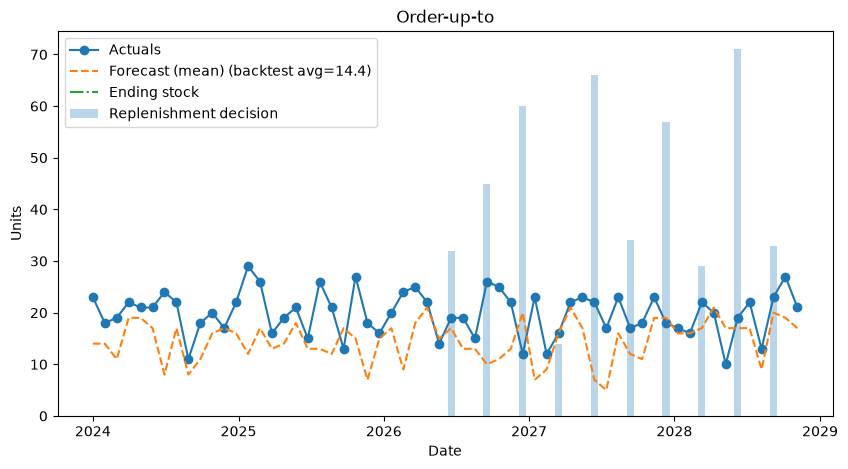

In [6]:
example_id = order_up_to_df["unique_id"].iloc[0]
plot_replenishment_decisions(rows_df, order_up_to_df, unique_id=example_id, title="Order-up-to")

### 2.2 Reorder-point

<Axes: title={'center': 'Reorder-point'}, xlabel='Date', ylabel='Units'>

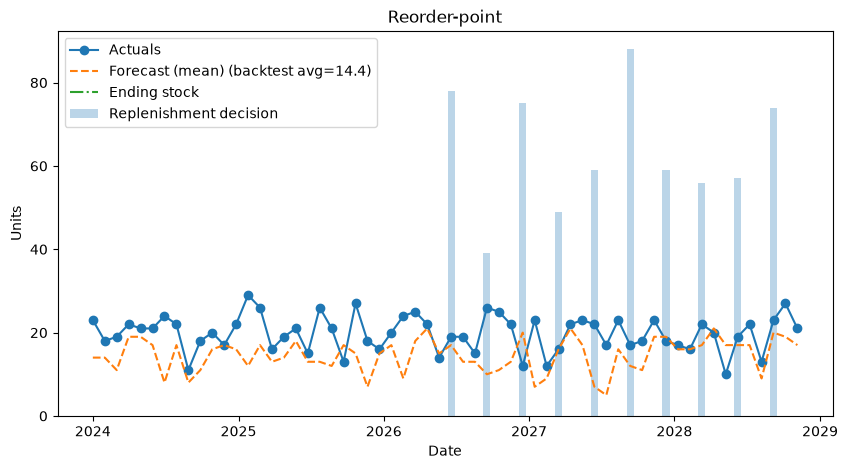

In [7]:
plot_replenishment_decisions(rows_df, reorder_point_df, unique_id=example_id, title="Reorder-point")